<a href="https://colab.research.google.com/github/Omprakash143om/SHOE-IMAGE_DETECTION/blob/PROGRAMS/Deeplearning_Imagedetection_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [41]:
# ✅ Step 1: Import required libraries
import numpy as np
import os
from PIL import Image
from random import shuffle
import matplotlib.pyplot as plt
from tqdm import tqdm

In [42]:
# ✅ Step 2: Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [43]:
# ✅ Step 3: Set Paths and Constants
TRAIN_DIR = '/content/drive/MyDrive/TRAIN'
TEST_DIR = '/content/drive/MyDrive/TEST'
IMG_SIZE = 120

In [44]:
# ✅ Step 4: Define label extraction function from file name
def label_image(filename):
    if filename.upper().startswith('NIKE'):
        return [1, 0]
    elif filename.upper().startswith('ADIDAS'):
        return [0, 1]
    else:
        return None  # Unknown or invalid file


In [45]:
# ✅ Step 5: Create training data from flat folder
def create_train_data():
    training_data = []
    VALID_EXTS = ('.jpg', '.jpeg', '.png', '.webp')
    for file in tqdm(os.listdir(TRAIN_DIR), desc="Loading training images"):
        if file.lower().endswith(VALID_EXTS):
            label = label_image(file)
            if label is not None:
                try:
                    path = os.path.join(TRAIN_DIR, file)
                    img = Image.open(path).convert('L')
                    img = img.resize((IMG_SIZE, IMG_SIZE), Image.Resampling.LANCZOS)
                    training_data.append([np.array(img), np.array(label)])
                except Exception as e:
                    print(f"Error loading {file}: {e}")
    shuffle(training_data)
    return training_data

train_data = create_train_data()
print("Total training images loaded:", len(train_data))


Loading training images: 100%|██████████| 100/100 [00:01<00:00, 99.48it/s]

Total training images loaded: 100


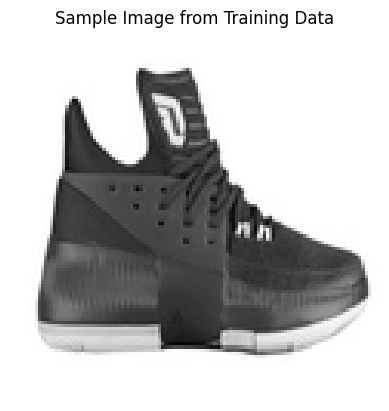

In [46]:
# ✅ Step 6: Show one sample image
if len(train_data) > 0:
    plt.imshow(train_data[0][0], cmap='gray')
    plt.title("Sample Image from Training Data")
    plt.axis('off')
    plt.show()
else:
    print("No training data found.")


In [47]:
# ✅ Step 7: Prepare data for model
X = np.array([i[0] for i in train_data]).reshape(-1, IMG_SIZE, IMG_SIZE, 1)
Y = np.array([i[1] for i in train_data])


In [48]:
# ✅ Step 8: Build CNN model
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

model = Sequential()
model.add(Conv2D(32, (5, 5), activation='relu', input_shape=(IMG_SIZE, IMG_SIZE, 1), padding='same'))
model.add(Conv2D(32, (5, 5), activation='relu', padding='same'))
model.add(MaxPooling2D(pool_size=(2, 2)))

model.add(Conv2D(64, (5, 5), activation='relu', padding='same'))
model.add(Conv2D(64, (5, 5), activation='relu', padding='same'))
model.add(MaxPooling2D(pool_size=(2, 2)))

model.add(Conv2D(128, (5, 5), activation='relu', padding='same'))
model.add(MaxPooling2D(pool_size=(2, 2)))

model.add(Flatten())
model.add(Dense(512, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(2, activation='softmax'))  # Output: [NIKE, ADIDAS]

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])


/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [49]:
# ✅ Step 9: Train the model
model.fit(X, Y, epochs=10, batch_size=32, validation_split=0.1)


Epoch 1/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 25s 7s/step - accuracy: 0.5674 - loss: 20.7287 - val_accuracy: 0.6000 - val_loss: 6.4061
Epoch 2/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 20s 7s/step - accuracy: 0.5551 - loss: 6.2137 - val_accuracy: 0.5000 - val_loss: 0.7015
Epoch 3/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 20s 6s/step - accuracy: 0.5942 - loss: 0.6524 - val_accuracy: 0.6000 - val_loss: 0.6781
Epoch 4/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 22s 7s/step - accuracy: 0.4883 - loss: 0.7194 - val_accuracy: 0.5000 - val_loss: 0.7156
Epoch 5/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 41s 7s/step - accuracy: 0.6298 - loss: 0.6548 - val_accuracy: 0.6000 - val_loss: 0.6760
Epoch 6/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 40s 6s/step - accuracy: 0.6119 - loss: 0.6628 - val_accuracy: 0.4000 - val_loss: 0.7634
Epoch 7/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 41s 6s/step - accuracy: 0.6314 - loss: 0.5924 - val_accuracy: 0.6000 - val_loss: 0.6900
Epoch 8/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 40s 6s/step - accuracy: 0.6843 - loss: 0.5828 - val_accuracy: 0.6000 - val_loss: 0.6709
Epoch 9

In [50]:
# ✅ Step 10: Define prediction function for any image
def predict_image(image_path):
    try:
        img = Image.open(image_path).convert('L')
        img = img.resize((IMG_SIZE, IMG_SIZE), Image.Resampling.LANCZOS)
        img_array = np.array(img).reshape(-1, IMG_SIZE, IMG_SIZE, 1)
        prediction = model.predict(img_array)[0]
        predicted_label = "NIKE" if np.argmax(prediction) == 0 else "ADIDAS"
        confidence = round(np.max(prediction) * 100, 2)

        plt.imshow(img, cmap='gray')
        plt.title(f"Prediction: {predicted_label} ({confidence}%)")
        plt.axis('off')
        plt.show()
    except Exception as e:
        print(f"Error: {e}")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step


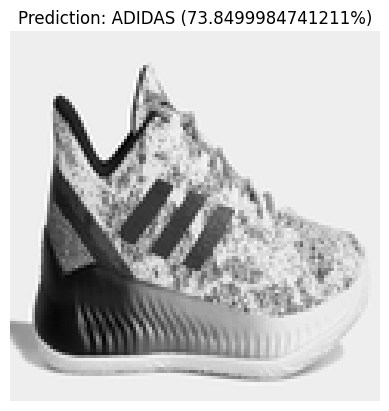

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step


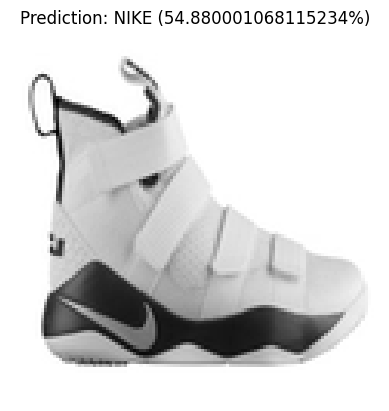

In [68]:
# ✅ Step 11: Test on your own images
predict_image('/content/drive/MyDrive/TEST/ADIDAS_63.png')
predict_image('/content/drive/MyDrive/TEST/NIKE_51.png')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step


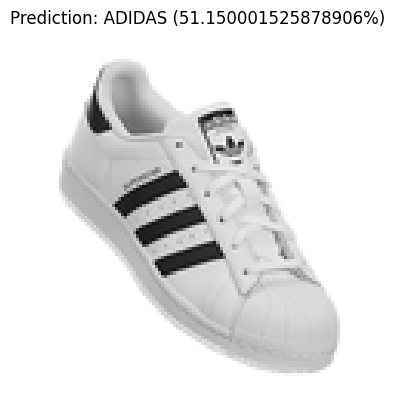

In [69]:
predict_image('/content/drive/MyDrive/adidastestimage.png')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 195ms/step


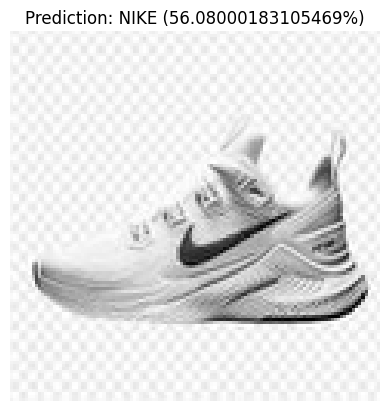

In [70]:
predict_image('/content/drive/MyDrive/niketet.jpeg')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step


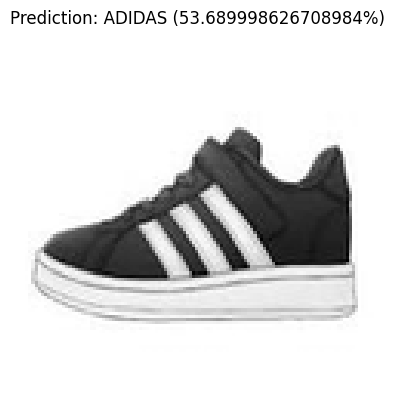

In [71]:
predict_image('/content/drive/MyDrive/adidastestimg.jpeg')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step


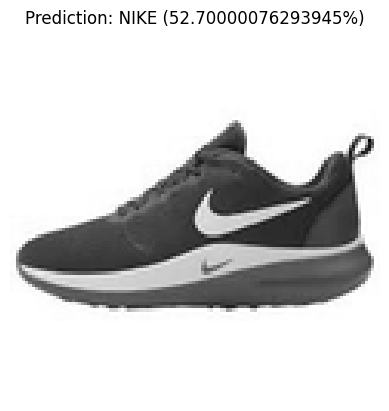

In [72]:
predict_image('/content/drive/MyDrive/NIKETEST.jpeg')